# Two moons example

In [2]:
import os

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from jaxili.inference import NPE, NLE

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, init_to_value

from getdist import plots, MCSamples

%matplotlib inline

print("Device used by jax:", jax.devices())

2025-03-12 20:33:45.535276: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1741808025.566392   24650 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1741808025.573762   24650 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Device used by jax: [CudaDevice(id=0)]


Two moons is a standard benchmark task where the posterior is bimodal. This is a good example to test the ability of NPE and NLE to sample from a complex posterior.

## Defining the simulator

We will try to solve the following inference problem:

- Prior: $\mathcal{U}(-1, 1)$
- Simulator: $x|\theta \sim \left[\begin{array}{c} r\cos(\alpha)+0.25 \\ r\sin(\alpha)\end{array}\right]+\left[ \begin{array}{c} -|\theta_1+\theta_2|/\sqrt{2}\\ (-\theta_1+\theta_2)/\sqrt{2} \end{array}\right]$ where $\alpha \sim \mathcal{U}(-\pi/2, \pi/2)$ and $r \sim \mathcal{N}(0.1, 0.01^2)$
- $\theta \in \mathbb{R}^2$, $x\in \mathbb{R}^2$

Let's implement the simulator.

In [3]:
def simulator(theta, rng_key):
    batch_size = theta.shape[0]

    # Sample angle
    alpha_key, rng_key = jax.random.split(rng_key)
    alpha = jax.random.uniform(
        alpha_key, (batch_size, 1), minval=-jnp.pi / 2, maxval=jnp.pi / 2
    )

    # Sample radius
    r_key, rng_key = jax.random.split(rng_key)
    r = jax.random.normal(r_key, (batch_size, 1)) * 0.01 + 0.1

    # Compute x_1 and x_2
    x_1 = (
        r * jnp.cos(alpha)
        + 0.25
        - jnp.abs(theta[:, 0] + theta[:, 1]).reshape((-1, 1)) / jnp.sqrt(2)
    )
    x_2 = r * jnp.sin(alpha) + (-theta[:, 0] + theta[:, 1]).reshape((-1, 1)) / jnp.sqrt(
        2
    )
    return jnp.column_stack([x_1, x_2])

Let's create the datatset.

In [4]:
master_key = jax.random.PRNGKey(0)

n_dim = 2
num_samples = 10_000
# Generate parameters
theta_key, master_key = jax.random.split(master_key)
theta = jax.random.uniform(theta_key, (num_samples, n_dim), minval=-1, maxval=1)

# Generate data
data_key, master_key = jax.random.split(master_key)
x = simulator(theta, data_key)

In [22]:
# Let's create a fiducial target
fiducial = jnp.array([[0.2, -0.5]])
obs = simulator(fiducial, jax.random.PRNGKey(0))

print("Fiducial parameters:", fiducial)
print("Fiducial observation:", obs)

Fiducial parameters: [[ 0.2 -0.5]]
Fiducial observation: [[ 0.08635053 -0.40524617]]


## Reference samples (HMC)

A first thing we can do is to collect reference samples using a standard MCMC technique. We will use Hamiltonian Monte Carlo using `numpyro`.

In [23]:
def model(obs):
    theta_1 = numpyro.sample("theta_1", dist.Uniform(-1, 1))
    theta_2 = numpyro.sample("theta_2", dist.Uniform(-1, 1))
    alpha = numpyro.sample("alpha", dist.Uniform(-jnp.pi / 2, jnp.pi / 2))
    r = numpyro.sample("r", dist.Normal(0.1, 0.01))

    x_1 = r * jnp.cos(alpha) + 0.25 - jnp.abs(theta_1 + theta_2) / jnp.sqrt(2)
    x_2 = r * jnp.sin(alpha) + (-theta_1 + theta_2) / jnp.sqrt(2)

    x = jnp.column_stack([x_1, x_2])

    numpyro.sample("obs", dist.Normal(x, 0.001), obs=obs)

In [33]:
init_values = {
    "theta_1": jnp.array([[0.2], [0.5]]),
    "theta_2": jnp.array([[-0.5], [-0.2]]),
    "alpha": jnp.array([[0.0], [0.0]]),
    "r": jnp.array([[0.1], [0.1]]),
}

nuts_kernel = NUTS(model, init_strategy=init_to_value(values=init_values))

mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=2000, num_chains=2)
rng_key = jax.random.PRNGKey(0)
mcmc.run(rng_key, obs=obs.squeeze())

/tmp/ipykernel_24650/1040535642.py:10: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=2000, num_chains=2)
sample: 100%|██████████| 3000/3000 [04:06<00:00, 12.16it/s, 511 steps of size 6.08e-03. acc. prob=0.93] 


In [37]:
posterior_samples = mcmc.get_samples()

In [38]:
samples = jnp.column_stack([posterior_samples["theta_1"], posterior_samples["theta_2"]])

In [41]:
samples.shape

(4000, 4, 1)

In [39]:
labels = [rf"\theta_{i}" for i in range(n_dim)]

reference_samples_gd = MCSamples(samples=samples, names=labels, labels=labels)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot(
    [reference_samples_gd],
    filled=True,
    line_args=[{"color": "black"}],
    contour_colors=["black"],
    markers={label: val for label, val in zip(labels, fiducial[0])},
)

plt.show()

Removed no burn in


WeightedSampleError: paramNames size (2) does not match number of parameters in samples (1)

## Neural Posterior Estimation (NPE)

Let's setup the pipeline. We create the inference object, we push the simulations, we train and we fetch the posterior!

In [12]:
inference = NPE()
inference = inference.append_simulations(np.array(theta), np.array(x))

[!] Inputs are valid.
[!] Appending 10000 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 7000 simulations.
[!] Validation set: 2000 simulations.
[!] Test set: 1000 simulations.


In [13]:
# Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "."
# Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)
learning_rate = 1e-3

num_epochs = 250

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=learning_rate,
)

[!] Creating DataLoaders with batch_size 50.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs: Val loss -3.342/ Best val loss -3.352:  54%|█████▎    | 134/250 [00:31<00:27,  4.29it/s]

Neural network training stopped after 135 epochs.
Early stopping with best validation metric: -3.351813554763794
Best model saved at epoch 114
Early stopping parameters: min_delta=0.001, patience=20
[!] Training loss: -3.461625814437866
[!] Validation loss: -3.351813554763794
[!] Test loss: -3.3102118968963623


In [14]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


## Checking the posterior

In [15]:
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(x=obs, num_samples=10_000, key=sample_key)

Removed no burn in


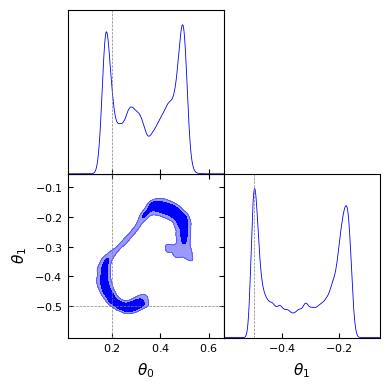

In [16]:
labels = [rf"\theta_{i}" for i in range(n_dim)]

samples_gd = MCSamples(samples=samples, names=labels, labels=labels)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot(
    [samples_gd],
    filled=True,
    line_args=[{"color": "blue"}],
    contour_colors=["blue"],
    markers={label: val for label, val in zip(labels, fiducial[0])},
)

plt.show()

## Neural Likelihood Estimation (NLE)

Likewise, we can learn the likelihood before sampling the posterior.

In [10]:
inference = NLE()
inference = inference.append_simulations(np.array(theta), np.array(x))

/home/sacha/anaconda3/envs/jaxili/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


[!] Inputs are valid.
[!] Appending 10000 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 7000 simulations.
[!] Validation set: 2000 simulations.
[!] Test set: 1000 simulations.


In [10]:
# Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "."
# Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 250

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
)

TypeError: TrainerModule.train_model() got an unexpected keyword argument 'checkpoint_path'

In [15]:
posterior = inference.build_posterior(
    prior_distr=dist.Uniform(low=jnp.array([-1, -1]), high=jnp.array([1, 1])),
    mcmc_kwargs={"num_chains": 10},
)

Using MCMC method: nuts_numpyro
MCMC kwargs: {'num_chains': 10}
[!] Posterior $p(\theta| x)$ built. The class MCMCPosterior is used to sample and evaluate the log probability.\n The sampling is performed using MCMC methods.


In [16]:
num_samples = 2_500
sample_key, master_key = jax.random.split(master_key)
samples_nle = posterior.sample(x=obs, num_samples=num_samples, key=sample_key)

/home/sacha/anaconda3/envs/jaxili/lib/python3.10/site-packages/jaxili/posterior/mcmc_posterior.py:243: UserWarning: There are not enough devices to run parallel chains: expected 10 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(10)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(
sample: 100%|██████████| 3000/3000 [00:29<00:00, 100.09it/s, 13 steps of size 1.40e-01. acc. prob=0.94]


Removed no burn in
Removed no burn in


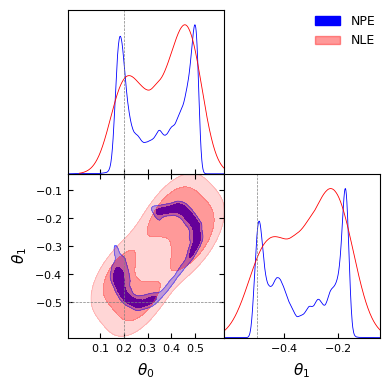

In [17]:
labels = [rf"\theta_{i}" for i in range(n_dim)]

samples_gd = MCSamples(samples=samples, names=labels, labels=labels)
samples_nle_gd = MCSamples(samples=samples_nle, names=labels, labels=labels)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot(
    [samples_gd, samples_nle_gd],
    filled=True,
    line_args=[{"color": "blue"}, {"color": "red"}],
    legend_labels=["NPE", "NLE"],
    contour_colors=["blue", "red"],
    markers={label: val for label, val in zip(labels, fiducial[0])},
)

plt.show()